In [1]:
#import os
#os.environ.pop("MPLBACKEND", None)

from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from umap import UMAP
from sklearn.cluster import HDBSCAN
import json
import glob
import os
import json
import random
from sklearn.metrics.pairwise import cosine_distances
import seaborn as sns
import torch
import re

#from google.colab import drive
#drive.mount('/content/drive',force_remount=True)

POPULATION_DIR = "/scratch/mansisak/llm_optimizer/curated_initial_populations_v2"
POPULATION_DYNAMICS_RESULTS = "/scratch/mansisak/llm_optimizer/pop_dynamics"

# Use the GPU for embedding if this kernel has one visible (e.g. running inside a Slurm
# GPU allocation); every SentenceTransformer(...) call below passes device=DEVICE.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {DEVICE}")

# Rollout directory names in population_dynamics/ and perturb/ all start with
# "opro_<model>_...". Shared here so both analysis sections stratify consistently.
MODEL_PATTERN = re.compile(r"^opro_(gemini-25-flash|gemini-35-flash|openaigpt-oss-120b)_")
MODEL_LABELS = {
    'gemini-25-flash': 'Gemini 2.5 Flash',
    'gemini-35-flash': 'Gemini 3.5 Flash',
    'openaigpt-oss-120b': 'GPT-OSS-120B',
}
MODEL_ORDER = ['Gemini 2.5 Flash', 'Gemini 3.5 Flash', 'GPT-OSS-120B']


def extract_model_label(run_dir):
    basename = os.path.basename(run_dir.rstrip('/'))
    m = MODEL_PATTERN.match(basename)
    if not m:
        return None
    return MODEL_LABELS[m.group(1)]

Embedding device: cuda


In [2]:
# Define your parameter settings
noise_settings = [0.0, 0.1, 0.5, 1.0]
n_settings = [3, 5, 10, 20, 0]

# List to store individual DataFrames
all_dfs = []

# Loop over every combination of n and noise
for n, noise in itertools.product(n_settings, noise_settings):
    df_path = f"/scratch/mansisak/llm_optimizer/temp_results_dir/tweet_{n}_{noise}/solution_bank.json"

    # Check if the file exists to prevent your loop from crashing on missing data
    if os.path.exists(df_path):
        # 1. Read the JSON file
        df = pd.read_json(df_path, orient='index')

        # 2. Reset index and rename columns
        df = df.reset_index()
        df.columns = ['iter_num', 'solution_str', 'score_num']

        # 3. Add tracking columns for context
        df['n'] = n
        df['noise'] = noise

        # Append to our tracking list
        all_dfs.append(df)
    else:
        print(f"Warning: File not found at {df_path}")

# Concatenate all DataFrames into one, ignoring indices to prevent duplicates
if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Successfully combined {len(all_dfs)} files.")
else:
    print("No data was found or loaded.")

final_df.head()

Successfully combined 20 files.


,iter_num,solution_str,score_num,n,noise
0,0,Imagine getting a standing ovation for not set...,0.008827,3,0.0
1,1,Imagine getting a standing ovation for finally...,0.000833,3,0.0
2,2,Imagine getting a standing ovation for putting...,0.019719,3,0.0
3,3,Imagine getting a standing ovation for not cra...,0.004974,3,0.0
4,4,Imagine getting a standing ovation for doing y...,0.001041,3,0.0


# Create a gradient of populations w/ varying inital score vs. diversity dynamics



In [ ]:
import numpy as np

# 1. Establish the bounding cutoffs for your 4 rows using the df column
score_edges = np.quantile(final_df['score_num'], [0, 0.25, 0.50, 0.75, 1.0])

# 2. Group solutions into 4 discrete rows based on their scores
rows = []
for r in range(4):
    s_min, s_max = score_edges[r], score_edges[r+1]

    # Filter the DataFrame directly using a boolean mask
    row_pool = final_df[(final_df['score_num'] >= s_min) & (final_df['score_num'] <= s_max)].copy()

    rows.append(row_pool)

for idx, r_df in enumerate(rows):
    mean_score = r_df['score_num'].mean()
    count = len(r_df)
    print(f"Row {idx+1} -> Count: {count} solutions | Average Score: {mean_score:.4f}")



Row 1 -> Count: 250 solutions | Average Score: 0.0032
Row 2 -> Count: 250 solutions | Average Score: 0.0417
Row 3 -> Count: 252 solutions | Average Score: 0.2040
Row 4 -> Count: 253 solutions | Average Score: 0.4568


In [4]:

def generate_and_save_16_populations(df, output_dir, seed=42):
    os.makedirs(output_dir, exist_ok=True)

    random.seed(seed)
    np.random.seed(seed)

    clean_df = df.drop_duplicates(subset=['solution_str']).copy()
    print(f"Pool size after deduplication: {len(clean_df)} solutions.")

    print("Generating semantic embeddings...")
    model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
    embeddings = model.encode(clean_df['solution_str'].tolist(), show_progress_bar=False)
    clean_df['embedding'] = list(embeddings)

    score_edges = np.quantile(clean_df['score_num'], [0, 0.25, 0.50, 0.75, 1.0])
    experiment_matrix = {}

    thresholds = {
        "Col_1": (0.00, 0.15),
        "Col_2": (0.15, 0.40),
        "Col_3": (0.50, 0.75),
        "Col_4": (0.75, 1.00)
    }

    for r in range(4):
        s_min, s_max = score_edges[r], score_edges[r+1]

        if r < 3:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] < s_max)].copy()
        else:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] <= s_max)].copy()

        if len(row_df) < 15:
            print(f"Warning: Row {r+1} too small ({len(row_df)} items). Using fallback random sampling.")
            row_solutions = row_df.to_dict('records')
            for name in thresholds.keys():
                pop_key = f"Row_{r+1}_{name}"
                sampled_population = random.choices(row_solutions, k=min(10, len(row_solutions)))
                save_population_json(sampled_population, pop_key, output_dir)
                experiment_matrix[pop_key] = sampled_population
            continue

        row_embeddings = np.array(row_df['embedding'].tolist())
        row_solutions = row_df.to_dict('records')

        row_centroid = np.mean(row_embeddings, axis=0).reshape(1, -1)
        distances_to_centroid = cosine_distances(row_embeddings, row_centroid).flatten()

        for idx, dist in enumerate(distances_to_centroid):
            row_solutions[idx]['_dist_to_center'] = dist

        row_solutions_sorted = sorted(row_solutions, key=lambda x: x['_dist_to_center'])
        n_items = len(row_solutions_sorted)

        for col_name, (low_pct, high_pct) in thresholds.items():
            pop_key = f"Row_{r+1}_{col_name}"

            start_idx = int(n_items * low_pct)
            end_idx = int(n_items * high_pct)
            sub_pool = row_solutions_sorted[start_idx:end_idx]

            # Dynamic fallback expansion if semantic boundaries are too restrictive
            if len(sub_pool) < 10:
                sub_pool = row_solutions_sorted[max(0, start_idx-10) : min(n_items, end_idx+10)]

            # --- CRITICAL SCORE VARIANCE CONTROL LOOP ---
            # Sort the semantic sub-pool by score_num to find a contiguous block with SD < 0.05
            sub_pool_sorted_by_score = sorted(sub_pool, key=lambda x: x['score_num'])

            sampled_population = []
            # Use a sliding window of size 10 to find a group satisfying the variance limit
            for i in range(len(sub_pool_sorted_by_score) - 9):
                candidate_window = sub_pool_sorted_by_score[i:i+10]
                candidate_scores = [item['score_num'] for item in candidate_window]

                if np.std(candidate_scores) < 0.05:
                    sampled_population = candidate_window
                    break # Found a valid tightly-bound score cluster!

            # Fallback Guard: If no contiguous block of 10 matches SD < 0.05,
            # forcefully pick the 10 closest scores in this sub-pool to minimize variance
            if not sampled_population:
                print(f" Variance Alert: Row_{r+1}_{col_name} couldn't easily find SD < 0.05. Forcing closest scores.")
                min_sd = float('inf')
                best_idx = 0
                for i in range(len(sub_pool_sorted_by_score) - 9):
                    candidate_scores = [item['score_num'] for item in sub_pool_sorted_by_score[i:i+10]]
                    current_sd = np.std(candidate_scores)
                    if current_sd < min_sd:
                        min_sd = current_sd
                        best_idx = i
                sampled_population = sub_pool_sorted_by_score[best_idx:best_idx+10]

            # Save and clean up metrics
            save_population_json(sampled_population, pop_key, output_dir)

            for item in sampled_population:
                item.pop('_dist_to_center', None)

            experiment_matrix[pop_key] = sampled_population

    print(f"\nSuccessfully built and saved 16 populations using seed {seed}!")
    return experiment_matrix

def save_population_json(sampled_list, pop_name, output_dir):
    print(pop_name)
    initial_pop = {}
    for idx, item in enumerate(sampled_list):
        initial_pop[str(idx)] = {
            'solution': item.get('solution_str'),
            'score': item.get('score_num'),
            'extra_info': {}
        }
    file_path = os.path.join(output_dir, f"{pop_name}.json")
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(initial_pop, f, indent=4, ensure_ascii=False)

# Execution
experiment_populations = generate_and_save_16_populations(final_df, POPULATION_DIR, seed=42)


Pool size after deduplication: 884 solutions.
Generating semantic embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_1_Col_4
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_2_Col_4
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_3_Col_4
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3
Row_4_Col_4

Successfully built and saved 16 populations using seed 42!


In [ ]:


# Lists to collect summary statistics for any further plotting
extended_summary = []

print(f"{'Population ID':<25} | {'Score (Mean ± SD)':<20} | {'Diversity Distance (Mean ± SD)':<25}")
print("-" * 76)

for pop_name, solutions_list in experiment_populations.items():
    pop_df = pd.DataFrame(solutions_list)
    embeddings = np.array(pop_df['embedding'].tolist())

    # 1. Score Calculations
    mean_score = pop_df['score_num'].mean()
    std_score = pop_df['score_num'].std() # Sample standard deviation (ddof=1)

    # 2. Pairwise Distance Calculations
    if len(embeddings) > 1:
        pairwise_dist = cosine_distances(embeddings)
        triu_idx = np.triu_indices_from(pairwise_dist, k=1)
        flat_distances = pairwise_dist[triu_idx]

        mean_div = np.mean(flat_distances)
        std_div = np.std(flat_distances) # Standard deviation of the 45 unique pairs
    else:
        mean_div = 0.0
        std_div = 0.0

    # Format and print the row cleanly
    score_str = f"{mean_score:.4f} ± {std_score:.4f}"
    div_str = f"{mean_div:.4f} ± {std_div:.4f}"
    print(f"{pop_name:<25} | {score_str:<20} | {div_str:<25}")

    # Parse string labels for tabular logging
    parts = pop_name.split('_')
    extended_summary.append({
        'Population': pop_name,
        'Row': f"Row {parts[1]}",
        'Column': f"Col {parts[3]}",
        'Score_Mean': mean_score,
        'Score_SD': std_score,
        'Diversity_Mean': mean_div,
        'Diversity_SD': std_div
    })

# Convert to DataFrame if you need to inspect or export as a CSV
extended_summary_df = pd.DataFrame(extended_summary)


Population ID             | Score (Mean ± SD)    | Diversity Distance (Mean ± SD)
----------------------------------------------------------------------------
Row_1_Col_1               | 0.0008 ± 0.0001      | 0.2450 ± 0.1304          
Row_1_Col_2               | 0.0008 ± 0.0001      | 0.4053 ± 0.1329          
Row_1_Col_3               | 0.0008 ± 0.0001      | 0.5158 ± 0.1412          
Row_1_Col_4               | 0.0007 ± 0.0001      | 0.7126 ± 0.1299          
Row_2_Col_1               | 0.0134 ± 0.0030      | 0.4520 ± 0.1652          
Row_2_Col_2               | 0.0126 ± 0.0018      | 0.5427 ± 0.1601          
Row_2_Col_3               | 0.0115 ± 0.0021      | 0.5638 ± 0.1692          
Row_2_Col_4               | 0.0105 ± 0.0013      | 0.7098 ± 0.2177          
Row_3_Col_1               | 0.1362 ± 0.0182      | 0.2246 ± 0.1089          
Row_3_Col_2               | 0.0922 ± 0.0098      | 0.4627 ± 0.1659          
Row_3_Col_3               | 0.0984 ± 0.0154      | 0.5627 ± 0.1380     

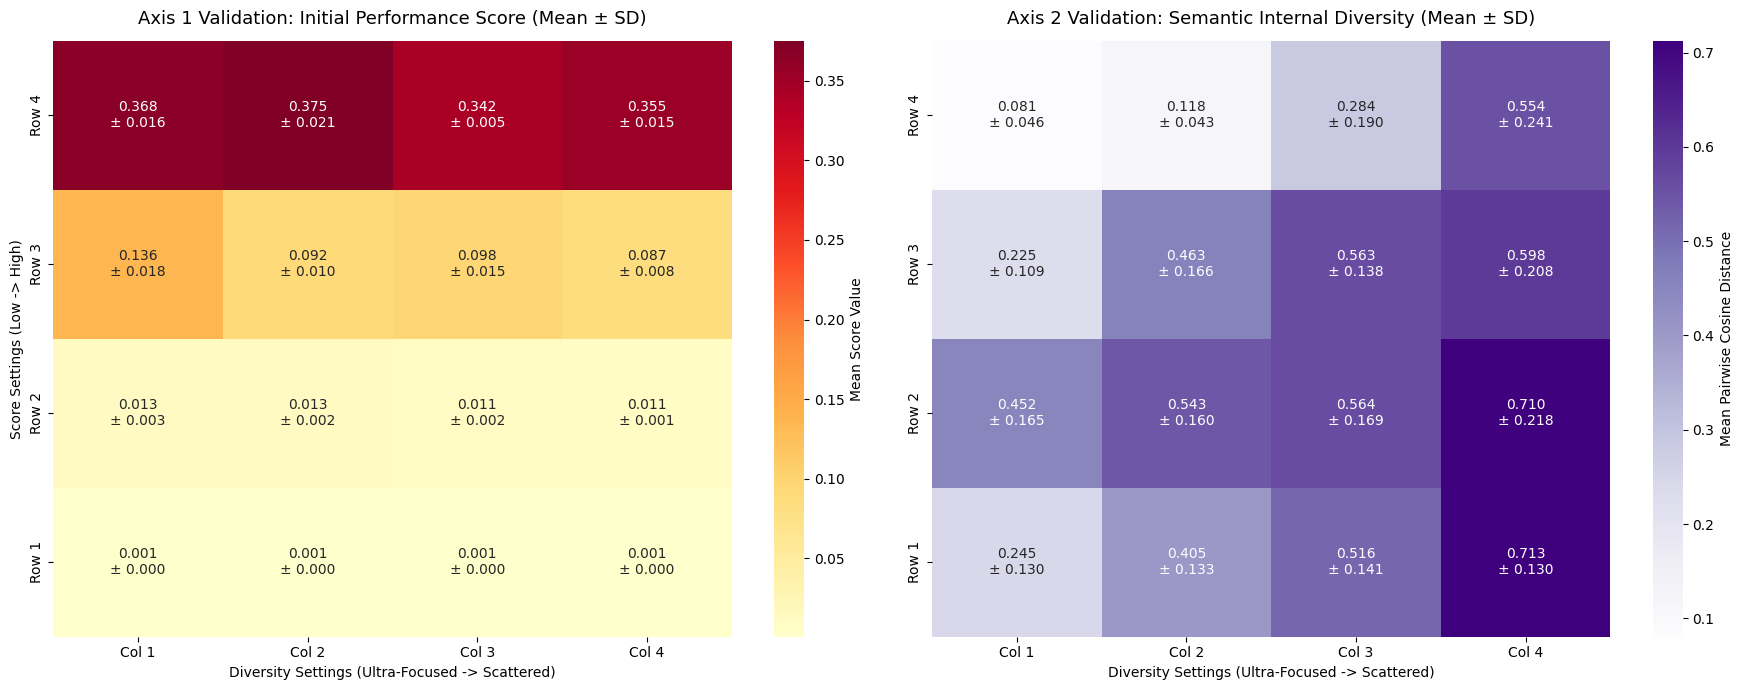

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pivot all metrics into 4x4 matrix forms
score_mean_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Score_Mean')
score_sd_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Score_SD')
div_mean_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Diversity_Mean')
div_sd_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Diversity_SD')

# 2. Enforce explicit order to match your grid layout
row_order = ['Row 4', 'Row 3', 'Row 2', 'Row 1']
col_order = ['Col 1', 'Col 2', 'Col 3', 'Col 4']

score_mean_mat = score_mean_mat.reindex(index=row_order, columns=col_order)
score_sd_mat = score_sd_mat.reindex(index=row_order, columns=col_order)
div_mean_mat = div_mean_mat.reindex(index=row_order, columns=col_order)
div_sd_mat = div_sd_mat.reindex(index=row_order, columns=col_order)

# 3. Create custom string label matrices combining Mean and SD
score_labels = score_mean_mat.copy().astype(str)
div_labels = div_mean_mat.copy().astype(str)

for r in row_order:
    for c in col_order:
        score_labels.loc[r, c] = f"{score_mean_mat.loc[r, c]:.3f}\n± {score_sd_mat.loc[r, c]:.3f}"
        div_labels.loc[r, c] = f"{div_mean_mat.loc[r, c]:.3f}\n± {div_sd_mat.loc[r, c]:.3f}"

# 4. Initialize the plot canvas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: INITIAL PERFORMANCE SCORE ---
sns.heatmap(score_mean_mat,
            annot=score_labels.values,  # Pass our formatted text matrix
            fmt="",                     # Required string formatting flag
            cmap="YlOrRd",
            ax=axes[0],
            annot_kws={"size": 10},     # Font size adjustment for 2-line annotations
            cbar_kws={'label': 'Mean Score Value'})
axes[0].set_title('Axis 1 Validation: Initial Performance Score (Mean ± SD)', fontsize=13, pad=12)
axes[0].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
axes[0].set_ylabel('Score Settings (Low -> High)')

# --- PANEL 2: INITIAL SEMANTIC DIVERSITY ---
sns.heatmap(div_mean_mat,
            annot=div_labels.values,
            fmt="",
            cmap="Purples",
            ax=axes[1],
            annot_kws={"size": 10},
            cbar_kws={'label': 'Mean Pairwise Cosine Distance'})
axes[1].set_title('Axis 2 Validation: Semantic Internal Diversity (Mean ± SD)', fontsize=13, pad=12)
axes[1].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
axes[1].set_ylabel('')  # Clear redundant label

plt.tight_layout()
plt.show()


### Analysis of Initialzation Experiments

We are going to make a zeris of 3 heatmaps stratified by diversity on the x axis and iniital score on the y axis (just like how we initialized the perturbations). Report std_dev for each value. There should be 4 heatmaps: 
1. maximum score, 
2. steps to maximum score, 
3. average diversity (average pair-wise cosine distances between embedded solutions in a given roll out), and 
4. the # of solutions that live in the top 75% of the score distribution in a given roll out.

Average over different aggregation types/muatators/population sizes (basically agregate over everything except the initial population)

Also make 2 scatter plots w/ a line of best fit and reports p and r^2 values: best score vs. initial diversity and best score vs. initial score.

In [7]:
import re
import glob
from scipy import stats

experiment_dir = "/scratch/mansisak/llm_optimizer/population_dynamics"

# `model` from the population-grid cell above is scoped inside generate_and_save_16_populations,
# so we need our own embedding model here to score the final populations of each rollout.
rollout_embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

# Each run directory encodes its full config (aggregation type, mutator, population size, etc.)
# in its name, with the initial population identity embedded as "Row_<r>_Col_<c>". We only need
# to recover Row/Col here -- every other knob gets averaged over, per the analysis plan.
run_dirs = glob.glob(os.path.join(experiment_dir, "*/"))
row_col_pattern = re.compile(r"Row_(\d)_Col_(\d)")
print(f"Found {len(run_dirs)} rollout run directories.")


def compute_rollout_metrics(run_dir, embed_model):
    long_path = os.path.join(run_dir, "long_running_solution_bank.json")
    current_path = os.path.join(run_dir, "current_solution_bank.json")
    if not (os.path.exists(long_path) and os.path.exists(current_path)):
        return None

    with open(long_path, 'r', encoding='utf-8') as f:
        long_bank = json.load(f)
    with open(current_path, 'r', encoding='utf-8') as f:
        current_bank = json.load(f)

    if not long_bank or not current_bank:
        return None

    # Full score trajectory across the rollout, in iteration order.
    iters = sorted(long_bank.keys(), key=lambda k: int(k))
    scores = np.array([long_bank[k]['score'] for k in iters])

    max_score = scores.max()
    steps_to_max_score = int(iters[int(np.argmax(scores))])

    # Final (current) population: the live set of solutions at the end of the rollout.
    final_solutions = [v['solution'] for v in current_bank.values()]
    final_scores = np.array([v['score'] for v in current_bank.values()])

    if len(final_solutions) > 1:
        final_embeddings = embed_model.encode(final_solutions, show_progress_bar=False)
        pairwise_dist = cosine_distances(final_embeddings)
        triu_idx = np.triu_indices_from(pairwise_dist, k=1)
        avg_diversity = pairwise_dist[triu_idx].mean()
    else:
        avg_diversity = 0.0

    # Count of final-population solutions scoring at/above the 75th percentile of every
    # score this rollout ever produced (long_running_solution_bank) -- i.e. living in the
    # top quartile of the rollout's own score distribution.
    score_75th = np.quantile(scores, 0.75)
    n_top_quartile = int((final_scores >= score_75th).sum())

    return {
        'max_score': max_score,
        'steps_to_max_score': steps_to_max_score,
        'avg_diversity': avg_diversity,
        'n_top_quartile': n_top_quartile,
    }


records = []
skipped = 0
for run_dir in run_dirs:
    m = row_col_pattern.search(run_dir)
    model_label = extract_model_label(run_dir)
    if not m or model_label is None:
        print(f"Warning: could not parse Row/Col/model from {run_dir}")
        skipped += 1
        continue

    metrics = compute_rollout_metrics(run_dir, rollout_embed_model)
    if metrics is None:
        print(f"Warning: missing/empty solution bank in {run_dir}")
        skipped += 1
        continue

    metrics['Row'] = f"Row {m.group(1)}"
    metrics['Column'] = f"Col {m.group(2)}"
    metrics['Model'] = model_label
    metrics['run_dir'] = os.path.basename(run_dir.rstrip('/'))
    records.append(metrics)

rollout_df = pd.DataFrame(records)
print(f"Parsed {len(rollout_df)} / {len(run_dirs)} rollout runs ({skipped} skipped).")
print(rollout_df.groupby(['Row', 'Column', 'Model']).size().rename('n_configs'))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Found 384 rollout run directories.
Parsed 384 / 384 rollout runs (0 skipped).
Row    Column  Model           
Row 1  Col 1   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 2   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 3   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 4   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
Row 2  Col 1   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 2   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 3   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
       Col 4   GPT-OSS-120B        8
               Gemini 2.5 Flash    8
               Gemini 3.5 Flash    8
Ro

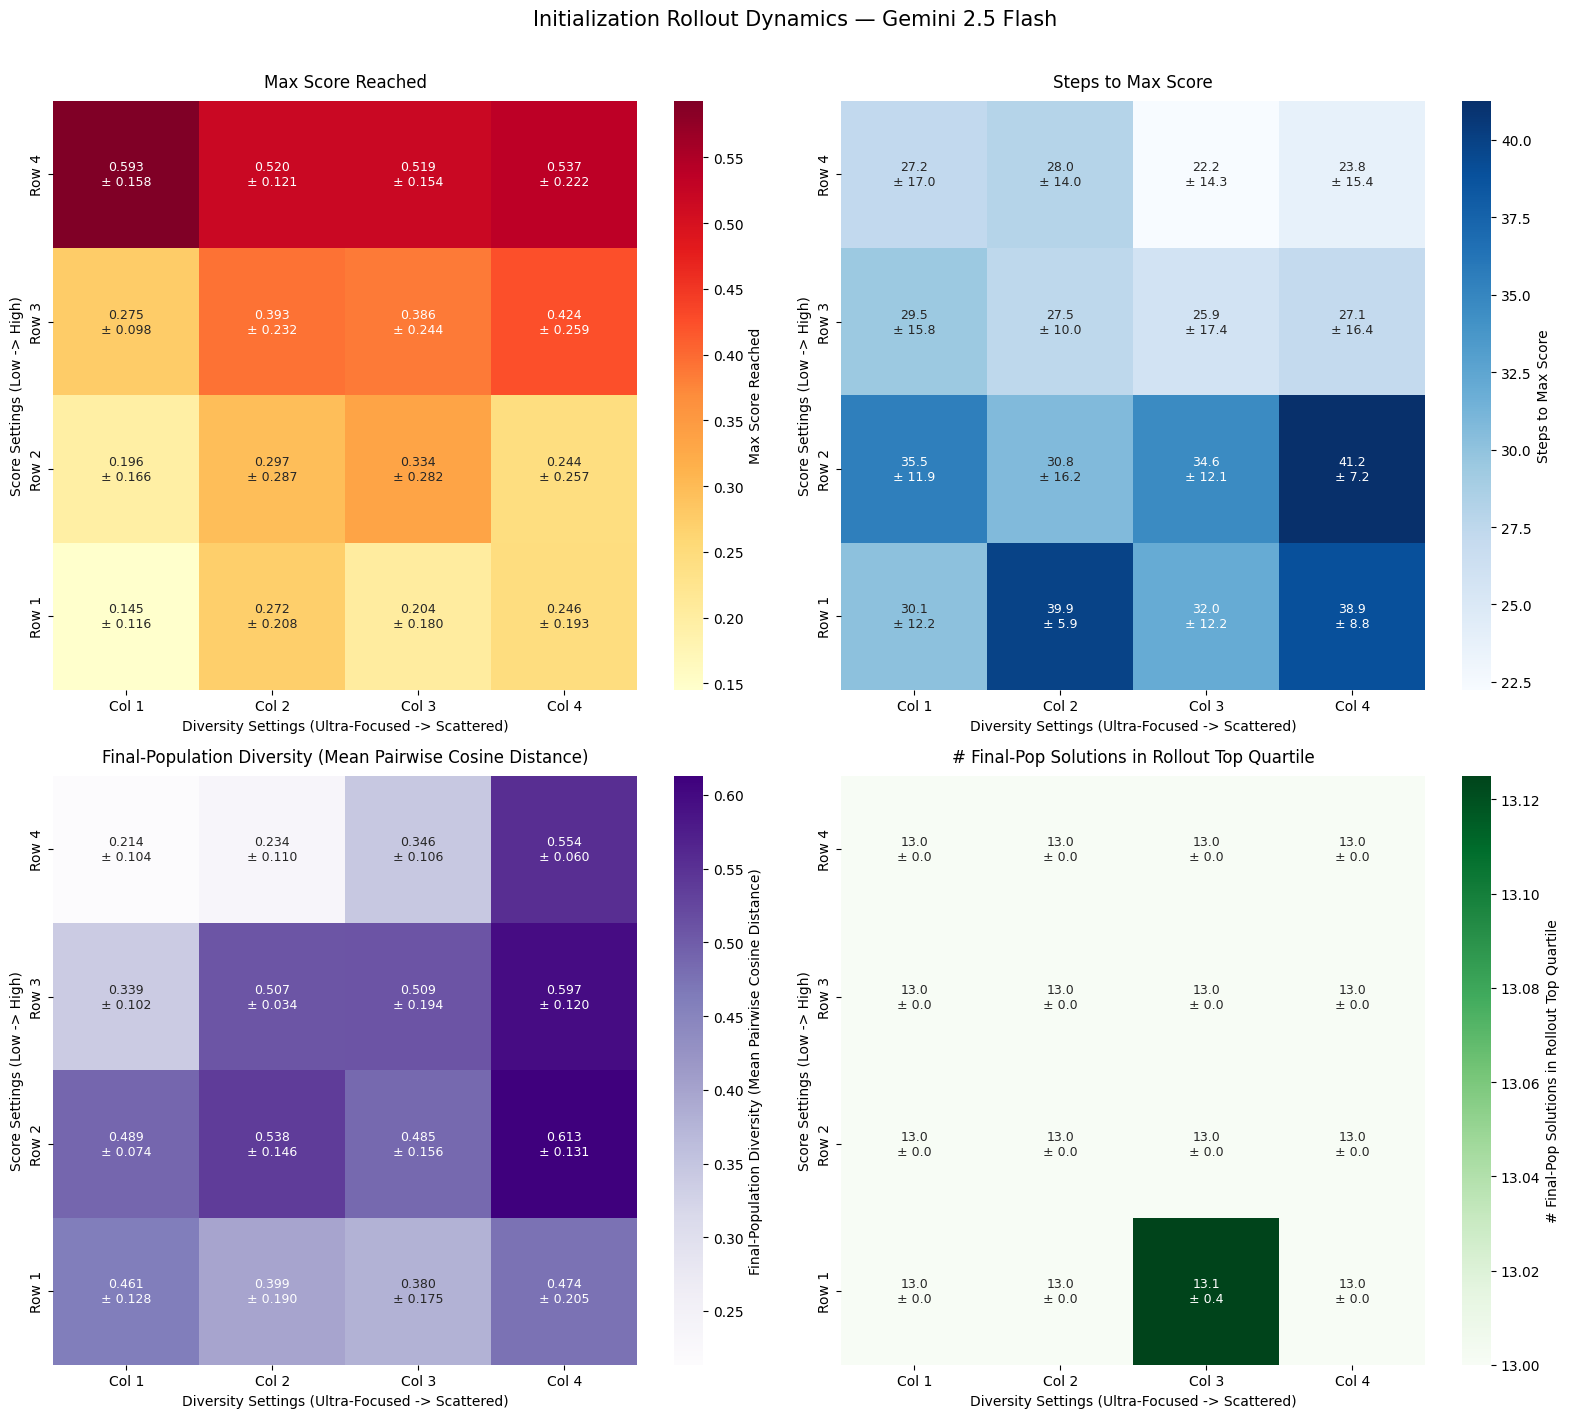

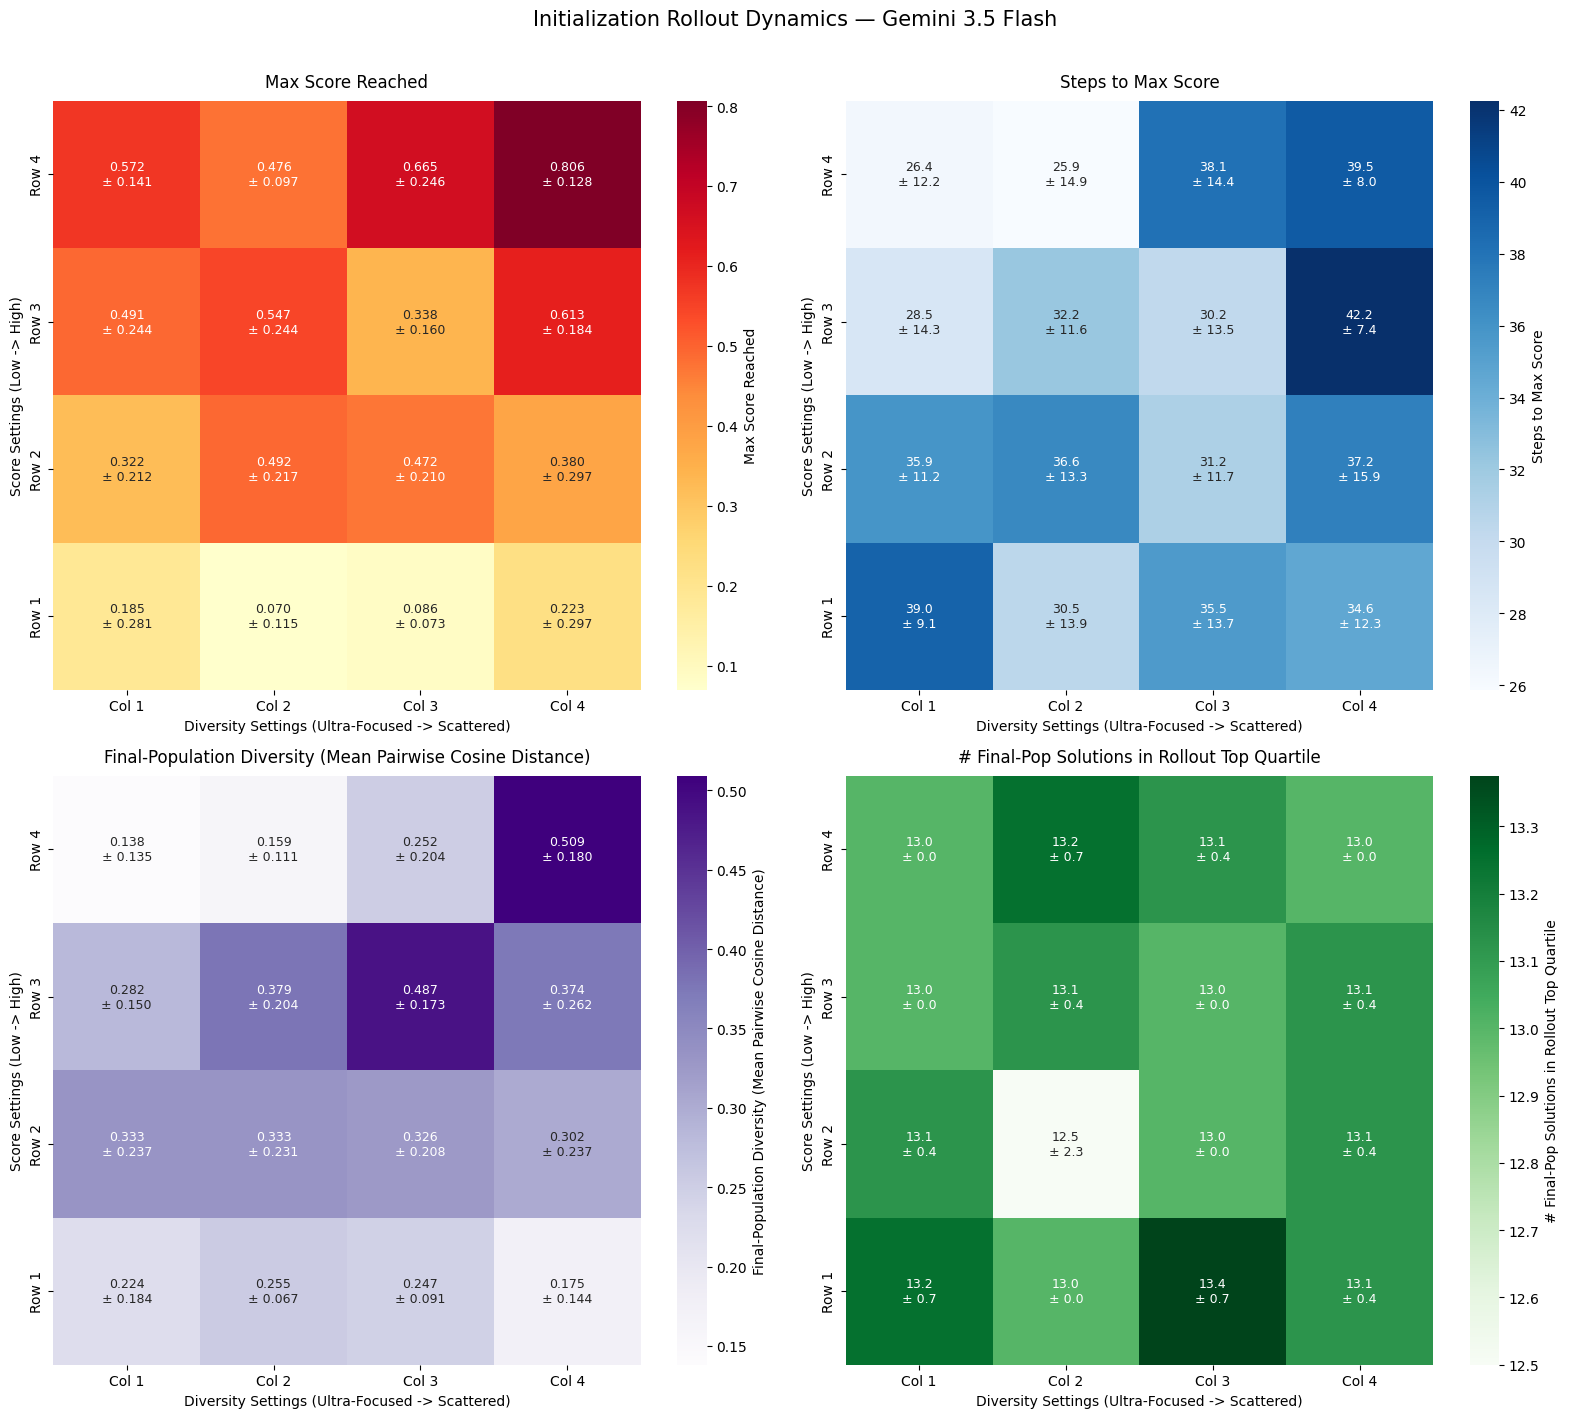

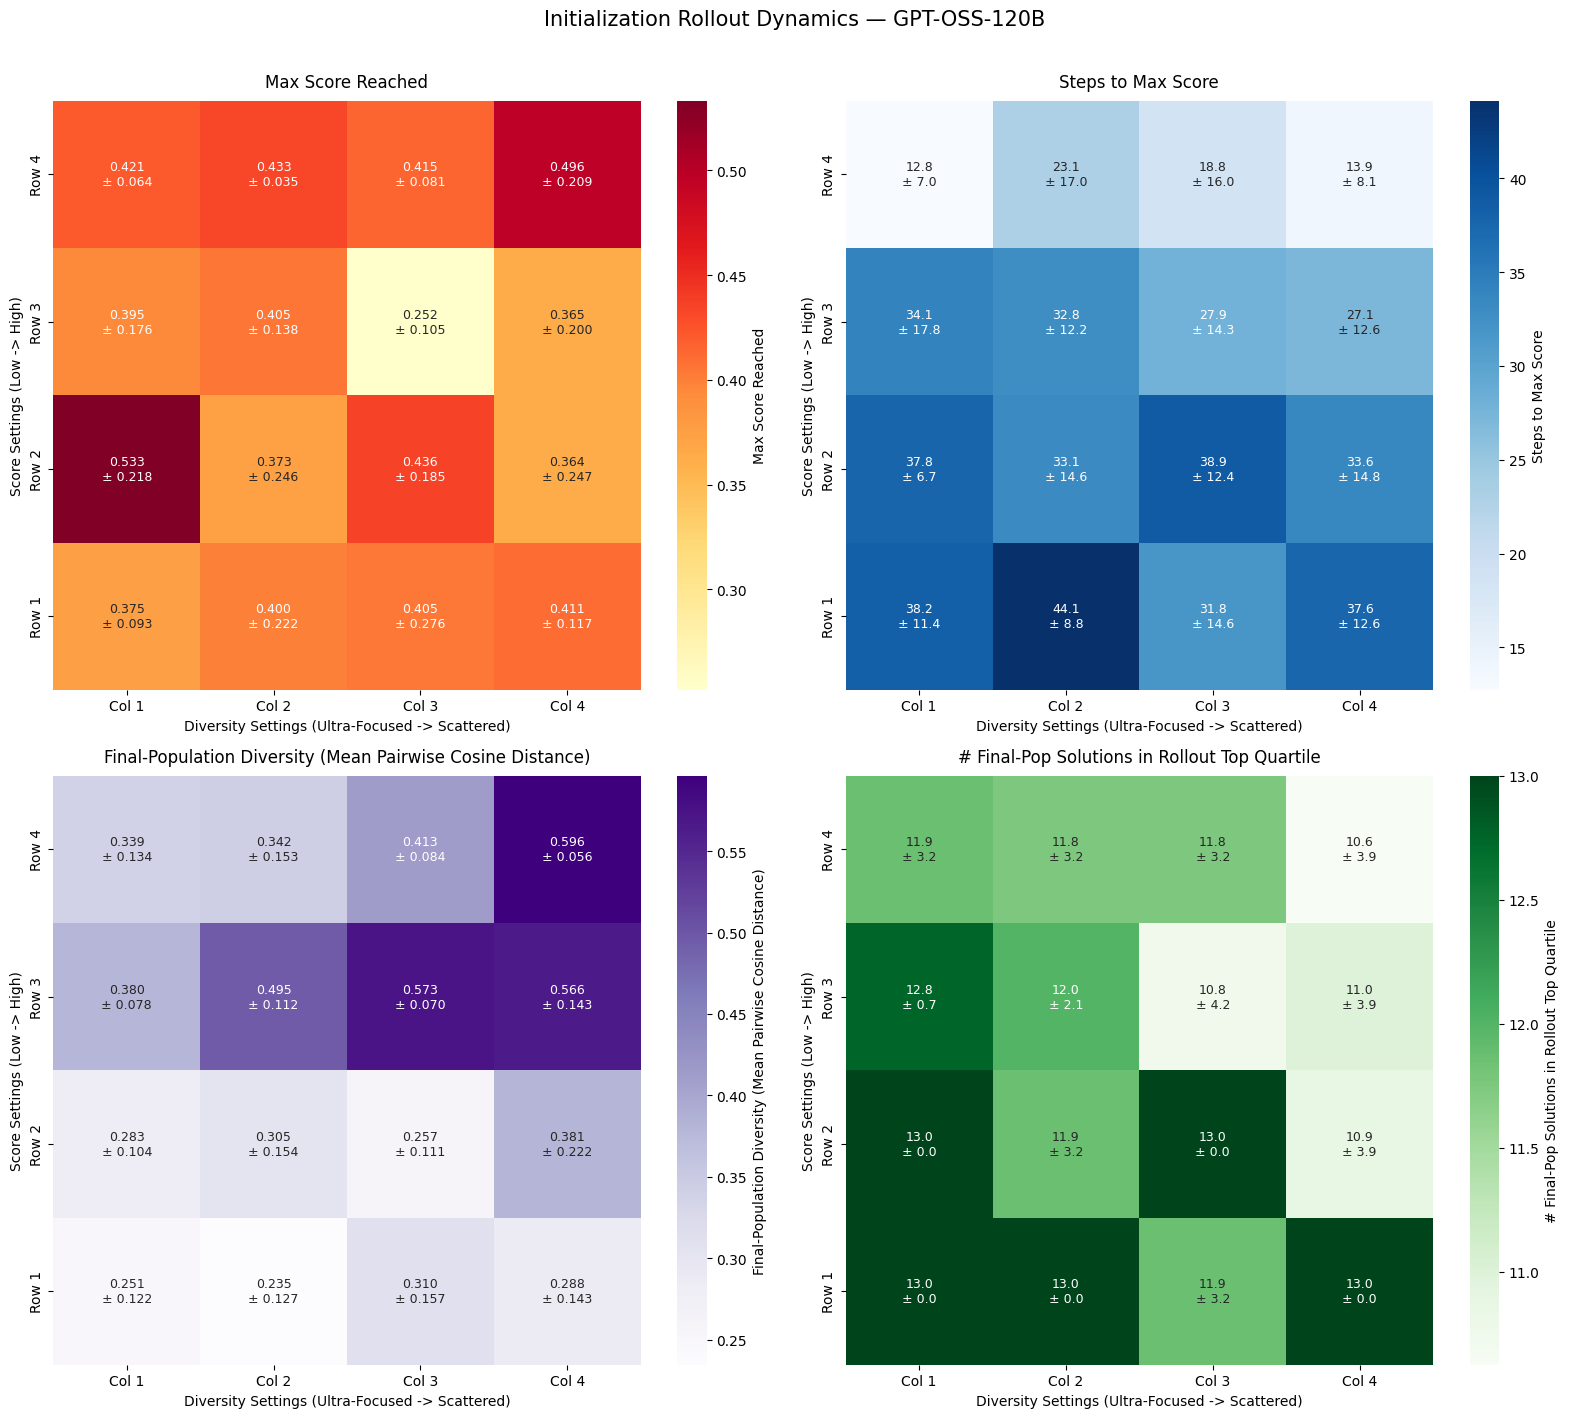

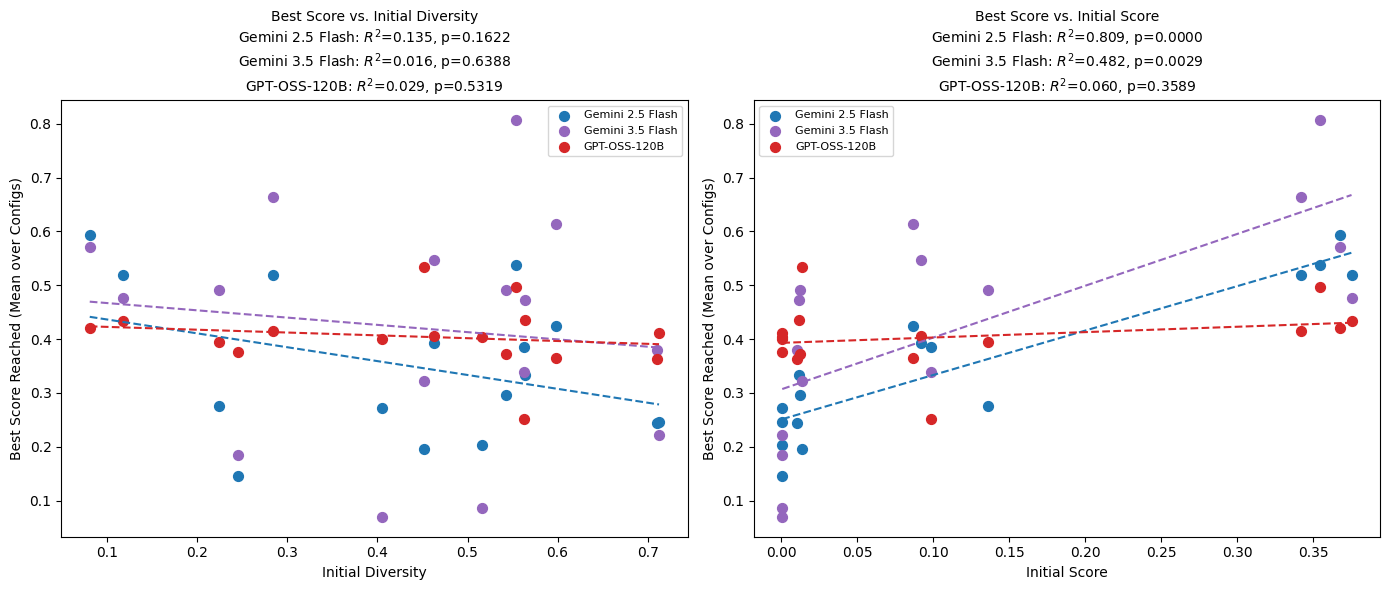

In [8]:
# --- Aggregate rollout outcomes per (initial population x model), averaging over
# every other knob (aggregation type, mutator, population size, etc.) ---
metric_cols = ['max_score', 'steps_to_max_score', 'avg_diversity', 'n_top_quartile']

rollout_agg = rollout_df.groupby(['Row', 'Column', 'Model'])[metric_cols].agg(['mean', 'std'])
rollout_agg.columns = ['_'.join(c) for c in rollout_agg.columns]
rollout_agg = rollout_agg.reset_index()

row_order = ['Row 4', 'Row 3', 'Row 2', 'Row 1']
col_order = ['Col 1', 'Col 2', 'Col 3', 'Col 4']

heatmap_specs = [
    ('max_score', 'YlOrRd', 'Max Score Reached', '{:.3f}'),
    ('steps_to_max_score', 'Blues', 'Steps to Max Score', '{:.1f}'),
    ('avg_diversity', 'Purples', 'Final-Population Diversity (Mean Pairwise Cosine Distance)', '{:.3f}'),
    ('n_top_quartile', 'Greens', '# Final-Pop Solutions in Rollout Top Quartile', '{:.1f}'),
]

# One 2x2 heatmap grid per model, so the score/diversity dynamics can be compared
# side by side across mutator LLMs.
for model_label in MODEL_ORDER:
    model_agg = rollout_agg[rollout_agg['Model'] == model_label]
    if model_agg.empty:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    fig.suptitle(f"Initialization Rollout Dynamics — {model_label}", fontsize=15, y=1.01)

    for ax, (metric, cmap, title, fmt) in zip(axes, heatmap_specs):
        mean_mat = model_agg.pivot(index='Row', columns='Column', values=f'{metric}_mean').reindex(index=row_order, columns=col_order)
        sd_mat = model_agg.pivot(index='Row', columns='Column', values=f'{metric}_std').reindex(index=row_order, columns=col_order)

        labels = mean_mat.copy().astype(str)
        for r in row_order:
            for c in col_order:
                labels.loc[r, c] = f"{fmt.format(mean_mat.loc[r, c])}\n± {fmt.format(sd_mat.loc[r, c])}"

        sns.heatmap(mean_mat, annot=labels.values, fmt="", cmap=cmap, ax=ax,
                    annot_kws={"size": 9}, cbar_kws={'label': title})
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
        ax.set_ylabel('Score Settings (Low -> High)')

    plt.tight_layout()
    plt.show()

# --- Join aggregated rollout outcomes back to each population's initial score/diversity
# (computed earlier in extended_summary_df) for the two scatter plots below. Initial
# score/diversity only depend on Row/Column, not Model, so this broadcasts across models. ---
init_stats = extended_summary_df[['Row', 'Column', 'Score_Mean', 'Diversity_Mean']].rename(
    columns={'Score_Mean': 'Initial_Score', 'Diversity_Mean': 'Initial_Diversity'}
)
scatter_df = rollout_agg.merge(init_stats, on=['Row', 'Column'])

model_colors = {'Gemini 2.5 Flash': 'tab:blue', 'Gemini 3.5 Flash': 'tab:purple', 'GPT-OSS-120B': 'tab:red'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_col, x_label in zip(
    axes, ['Initial_Diversity', 'Initial_Score'], ['Initial Diversity', 'Initial Score']
):
    stat_lines = []
    for model_label in MODEL_ORDER:
        model_df = scatter_df[scatter_df['Model'] == model_label]
        if model_df.empty:
            continue
        x = model_df[x_col].values
        y = model_df['max_score_mean'].values

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept

        color = model_colors[model_label]
        ax.scatter(x, y, s=50, color=color, label=model_label)
        ax.plot(x_line, y_line, color=color, linestyle='--')
        stat_lines.append(f"{model_label}: $R^2$={r_value**2:.3f}, p={p_value:.4f}")

    ax.set_xlabel(x_label)
    ax.set_ylabel('Best Score Reached (Mean over Configs)')
    ax.set_title(f'Best Score vs. {x_label}\n' + '\n'.join(stat_lines), fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Perturbation Populations: score-controlled, distance-graded replacement

**Goal:** isolate two independent variables -- *how many* candidates are swapped (`N`) and *how semantically far* the swaps come from (similarity tier) -- while holding score constant, in order to test whether even a small, real perturbation can destabilize a population's downstream behavior.

**Pipeline:**
1. **Medium-score band pool** -- filter to the 40th-65th percentile of `score_num`, dedupe, and embed with `all-MiniLM-L6-v2`. All distance-to-centroid percentiles below are computed against this single pool centroid.
2. **Base population (6 items)** -- drawn from the 35th-65th percentile of distance-to-centroid: medium diversity, *not* ultra-tight. An ultra-tight base would make any single swap look like a huge perturbation just because the base had no natural spread to begin with. Score is kept tight via a sliding-window search for the 6-item block with the lowest score SD (threshold `< 0.05`, same trick used for the earlier 16-population grid).
3. **Similarity tiers** -- three replacement-candidate pools, each a 30-point percentile window on distance-to-centroid, shifted +10 points further out per tier:
   - `Sim`: 45th-75th percentile -- a small but *real* step out, deliberately not overlapping into the base's own range (no no-ops)
   - `Med`: 55th-85th percentile
   - `Dissim`: 65th-95th percentile

   Within each tier, candidates are ranked by closeness of `score_num` to the base population's mean score, so replacements never drift the overall score.
4. **Fixed drop order** -- one seeded, arbitrary choice of 3 base slots to drop, reused identically across all three tiers. This isolates tier and `N` as independent variables: for a given `N`, the *only* difference between tiers is how far away the replacements are, never which base items were removed.
5. **Grid** -- for `tier in {Sim, Med, Dissim}` and `N in {1, 2, 3}`, build a population by dropping the first `N` slots (fixed order) and inserting that tier's `N` closest-scoring replacement candidates. Combined with `Base` (`N=0`), this gives 10 populations total.

Nothing is written to JSON yet in this section -- this is validation/exploration, mirroring the score/diversity heatmap check done for the original 16-population grid.


In [9]:
# --- Perturbation Populations: parameters ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Widened toward lower scores (was 0.40-0.65) so there are enough at-or-below-base-mean
# candidates for every similarity tier to draw from -- it's fine if the base population
# itself lands on a low-scoring cluster; what matters is that score stays tightly
# controlled across the whole grid, not that the base sits at a "medium" absolute score.
SCORE_BAND = (0.2, 0.55)          # percentile band on score_num defining the candidate pool
BASE_DIV_BAND = (0.10, 0.40)       # percentile band on distance-to-centroid for the base population
TIER_BANDS = {
    "Sim":    (0.40, 0.60),
    "Med":    (0.60, 0.80),
    "Dissim": (0.80, 1.00),
}
BASE_POP_SIZE = 6
SCORE_SD_THRESHOLD = 0.05
N_VALUES = [1, 2, 3]

# --- Build the score-band candidate pool and its embeddings ---
score_lo, score_hi = final_df['score_num'].quantile(list(SCORE_BAND))
pert_pool_df = (
    final_df[(final_df['score_num'] >= score_lo) & (final_df['score_num'] <= score_hi)]
    .drop_duplicates(subset=['solution_str'])
    .reset_index(drop=True)
)
pert_pool_df['uid'] = pert_pool_df.index
print(f"Score-band candidate pool: {len(pert_pool_df)} unique solutions "
      f"(score in [{score_lo:.4f}, {score_hi:.4f}])")

pert_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
pert_embeddings = pert_model.encode(pert_pool_df['solution_str'].tolist(), show_progress_bar=False)
pert_pool_df['embedding'] = list(pert_embeddings)

pool_centroid = np.mean(pert_embeddings, axis=0).reshape(1, -1)
pert_pool_df['dist_to_centroid'] = cosine_distances(pert_embeddings, pool_centroid).flatten()
pert_pool_df['dist_percentile'] = pert_pool_df['dist_to_centroid'].rank(pct=True)


def find_tight_score_window(candidates_df, window_size, sd_threshold):
    """Slide a score-sorted window of `window_size` looking for SD < sd_threshold;
    fall back to the lowest-SD window found if none qualify."""
    sorted_df = candidates_df.sort_values('score_num').reset_index(drop=True)
    n = len(sorted_df)
    if n < window_size:
        raise ValueError(f"Only {n} candidates available, need {window_size}.")

    best_idx, best_sd = 0, float('inf')
    for i in range(n - window_size + 1):
        window = sorted_df.iloc[i:i + window_size]
        sd = window['score_num'].std()
        if sd < sd_threshold:
            return window.copy()
        if sd < best_sd:
            best_sd, best_idx = sd, i

    print(f"  Variance Alert: no window with SD < {sd_threshold}; using best available (SD={best_sd:.4f}).")
    return sorted_df.iloc[best_idx:best_idx + window_size].copy()


base_candidates = pert_pool_df[
    (pert_pool_df['dist_percentile'] >= BASE_DIV_BAND[0]) &
    (pert_pool_df['dist_percentile'] <= BASE_DIV_BAND[1])
].copy()
print(f"Base diversity band candidates: {len(base_candidates)}")

base_population = find_tight_score_window(base_candidates, BASE_POP_SIZE, SCORE_SD_THRESHOLD)
base_score_mean = base_population['score_num'].mean()
base_score_sd = base_population['score_num'].std()
base_ids = set(base_population['uid'])
base_records = base_population.reset_index(drop=True).to_dict('records')

print(f"Base population: {len(base_records)} items | score {base_score_mean:.4f} ± {base_score_sd:.4f}")


Score-band candidate pool: 309 unique solutions (score in [0.0057, 0.1264])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Base diversity band candidates: 93
Base population: 6 items | score 0.0073 ± 0.0007


In [10]:
# --- Build the three similarity-tier replacement pools ---
# Tiers overlap on purpose (30-wide window shifted +10 per tier), but each candidate
# may only be claimed by the first (closest) tier it's eligible for -- otherwise the
# single best score-matching item in the pool can get picked by every tier, making
# e.g. N1_Sim == N1_Med == N1_Dissim identical populations.
#
# Score ranking is deliberately asymmetric: candidates AT OR BELOW base_score_mean are
# always preferred over candidates above it, even if an above-mean candidate is closer
# in absolute terms. A downstream rollout/evolution algorithm tends to latch onto and
# amplify high scorers early, so a replacement that's slightly higher-scoring than the
# base can quietly inflate the population's effective score as N grows -- exactly the
# drift we don't want in a score-controlled perturbation experiment. Only if a tier's
# band has too few at-or-below candidates do we fall back to above-mean ones.
used_ids = set(base_ids)
tier_queues = {}
for tier_name, (lo, hi) in TIER_BANDS.items():
    tier_pool = pert_pool_df[
        (~pert_pool_df['uid'].isin(used_ids)) &
        (pert_pool_df['dist_percentile'] >= lo) &
        (pert_pool_df['dist_percentile'] <= hi)
    ].copy()
    tier_pool['above_mean'] = tier_pool['score_num'] > base_score_mean
    tier_pool['score_gap'] = (tier_pool['score_num'] - base_score_mean).abs()
    tier_pool = tier_pool.sort_values(['above_mean', 'score_gap']).head(max(N_VALUES)).reset_index(drop=True)
    tier_queues[tier_name] = tier_pool
    used_ids |= set(tier_pool['uid'])

    n_above = int(tier_pool['above_mean'].sum())
    if n_above:
        print(f"  Note: {tier_name} had to reach for {n_above} above-mean candidate(s) "
              f"-- too few at-or-below-mean candidates in this band.")
    print(f"{tier_name:<7} using {len(tier_pool)} candidates biased at/below base score "
          f"(score_gap range {tier_pool['score_gap'].min():.4f}-{tier_pool['score_gap'].max():.4f})")

# --- Fixed drop order, identical across all tiers ---
slot_order = list(range(BASE_POP_SIZE))
random.shuffle(slot_order)
drop_order = slot_order[:max(N_VALUES)]
print(f"Fixed drop order (base slot indices, applied identically to every tier): {drop_order}")


def build_perturbed_population(base_records, drop_order, replacement_records, n):
    dropped = set(drop_order[:n])
    population = [item for idx, item in enumerate(base_records) if idx not in dropped]
    population += replacement_records[:n]
    return population


perturbation_populations = {"Base": base_records}
for tier_name, tier_df in tier_queues.items():
    replacement_records = tier_df.to_dict('records')
    for n in N_VALUES:
        key = f"N{n}_{tier_name}"
        perturbation_populations[key] = build_perturbed_population(
            base_records, drop_order, replacement_records, n
        )

print(f"\nBuilt {len(perturbation_populations)} populations "
      f"(1 base + {len(TIER_BANDS)} tiers x {len(N_VALUES)} N-values). Nothing saved to JSON yet.")


Sim     using 3 candidates biased at/below base score (score_gap range 0.0006-0.0012)
Med     using 3 candidates biased at/below base score (score_gap range 0.0003-0.0010)
  Note: Dissim had to reach for 1 above-mean candidate(s) -- too few at-or-below-mean candidates in this band.
Dissim  using 3 candidates biased at/below base score (score_gap range 0.0003-0.0009)
Fixed drop order (base slot indices, applied identically to every tier): [3, 1, 2]

Built 10 populations (1 base + 3 tiers x 3 N-values). Nothing saved to JSON yet.


In [ ]:
# --- Score / diversity summary for every perturbation population ---
pert_summary = []
print(f"{'Population':<12} | {'Score (Mean ± SD)':<20} | {'Diversity Distance (Mean ± SD)':<25}")
print("-" * 65)

for pop_name, solutions_list in perturbation_populations.items():
    pop_df = pd.DataFrame(solutions_list)
    embeddings = np.array(pop_df['embedding'].tolist())

    mean_score = pop_df['score_num'].mean()
    std_score = pop_df['score_num'].std()

    if len(embeddings) > 1:
        pairwise_dist = cosine_distances(embeddings)
        triu_idx = np.triu_indices_from(pairwise_dist, k=1)
        flat_distances = pairwise_dist[triu_idx]
        mean_div = np.mean(flat_distances)
        std_div = np.std(flat_distances)
    else:
        mean_div = std_div = 0.0

    print(f"{pop_name:<12} | {mean_score:.4f} ± {std_score:.4f}"
          f"{'':<6} | {mean_div:.4f} ± {std_div:.4f}")

    pert_summary.append({
        'Population': pop_name,
        'Score_Mean': mean_score,
        'Score_SD': std_score,
        'Diversity_Mean': mean_div,
        'Diversity_SD': std_div,
    })

pert_summary_df = pd.DataFrame(pert_summary)


Population   | Score (Mean ± SD)    | Diversity Distance (Mean ± SD)
-----------------------------------------------------------------
Base         | 0.0073 ± 0.0007       | 0.3619 ± 0.0720
N1_Sim       | 0.0071 ± 0.0007       | 0.3649 ± 0.0700
N2_Sim       | 0.0070 ± 0.0007       | 0.4416 ± 0.1218
N3_Sim       | 0.0068 ± 0.0008       | 0.5162 ± 0.1703
N1_Med       | 0.0072 ± 0.0007       | 0.4990 ± 0.1932
N2_Med       | 0.0071 ± 0.0007       | 0.5327 ± 0.1686
N3_Med       | 0.0070 ± 0.0007       | 0.5269 ± 0.1664
N1_Dissim    | 0.0071 ± 0.0007       | 0.4998 ± 0.1938
N2_Dissim    | 0.0070 ± 0.0008       | 0.6187 ± 0.2099
N3_Dissim    | 0.0071 ± 0.0008       | 0.6722 ± 0.2214


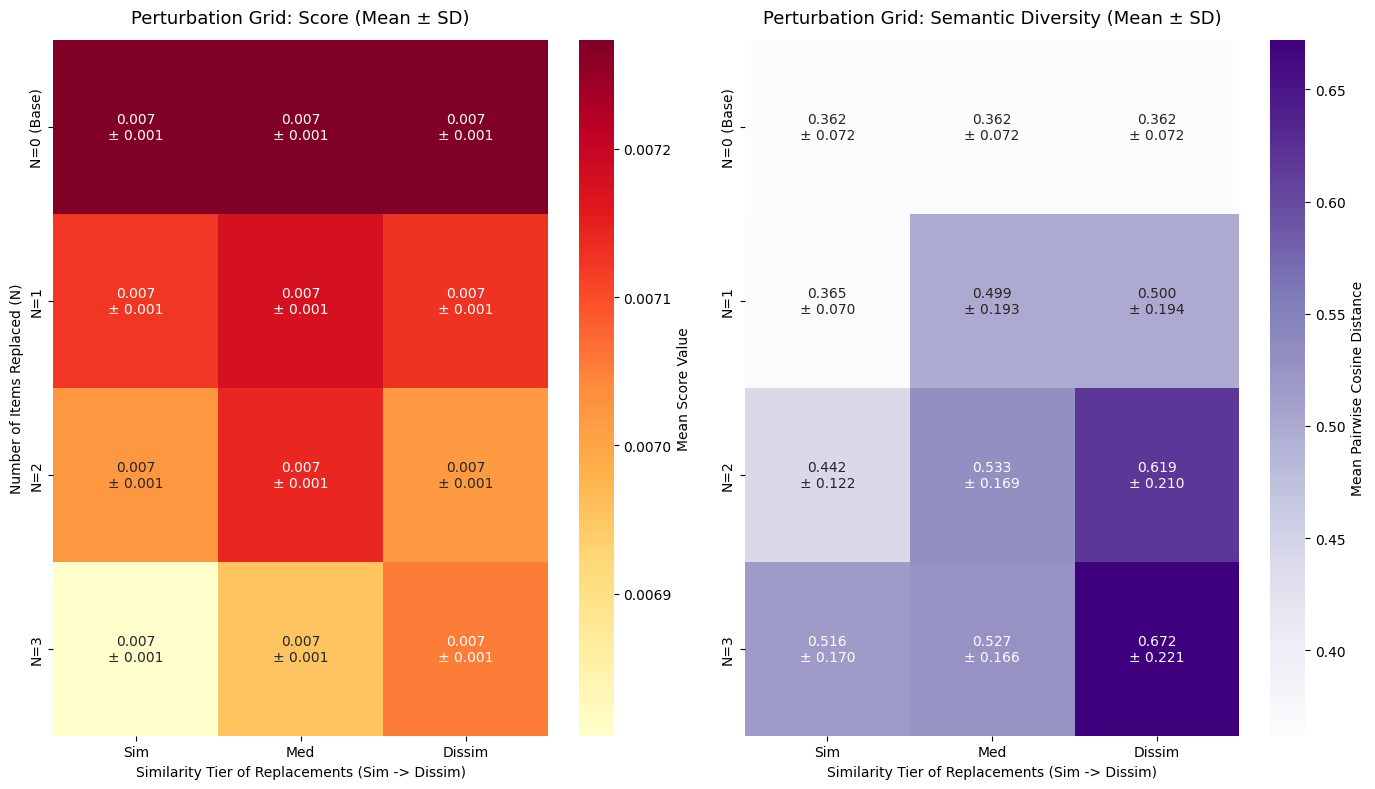

In [12]:
# --- Heatmap: N (replaced) x similarity tier, for score and diversity ---
tiers = list(TIER_BANDS.keys())
row_labels = ['N=0 (Base)'] + [f'N={n}' for n in N_VALUES]

def get_stats(pop_name):
    row = pert_summary_df.loc[pert_summary_df['Population'] == pop_name].iloc[0]
    return row['Score_Mean'], row['Score_SD'], row['Diversity_Mean'], row['Diversity_SD']

score_mean_mat = pd.DataFrame(index=row_labels, columns=tiers, dtype=float)
score_sd_mat = pd.DataFrame(index=row_labels, columns=tiers, dtype=float)
div_mean_mat = pd.DataFrame(index=row_labels, columns=tiers, dtype=float)
div_sd_mat = pd.DataFrame(index=row_labels, columns=tiers, dtype=float)

base_s_mean, base_s_sd, base_d_mean, base_d_sd = get_stats('Base')
for tier in tiers:
    score_mean_mat.loc['N=0 (Base)', tier] = base_s_mean
    score_sd_mat.loc['N=0 (Base)', tier] = base_s_sd
    div_mean_mat.loc['N=0 (Base)', tier] = base_d_mean
    div_sd_mat.loc['N=0 (Base)', tier] = base_d_sd

for n in N_VALUES:
    for tier in tiers:
        s_mean, s_sd, d_mean, d_sd = get_stats(f"N{n}_{tier}")
        score_mean_mat.loc[f'N={n}', tier] = s_mean
        score_sd_mat.loc[f'N={n}', tier] = s_sd
        div_mean_mat.loc[f'N={n}', tier] = d_mean
        div_sd_mat.loc[f'N={n}', tier] = d_sd

score_labels = score_mean_mat.copy().astype(str)
div_labels = div_mean_mat.copy().astype(str)
for r in row_labels:
    for c in tiers:
        score_labels.loc[r, c] = f"{score_mean_mat.loc[r, c]:.3f}\n± {score_sd_mat.loc[r, c]:.3f}"
        div_labels.loc[r, c] = f"{div_mean_mat.loc[r, c]:.3f}\n± {div_sd_mat.loc[r, c]:.3f}"

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(score_mean_mat, annot=score_labels.values, fmt="", cmap="YlOrRd", ax=axes[0],
            annot_kws={"size": 10}, cbar_kws={'label': 'Mean Score Value'})
axes[0].set_title('Perturbation Grid: Score (Mean ± SD)', fontsize=13, pad=12)
axes[0].set_xlabel('Similarity Tier of Replacements (Sim -> Dissim)')
axes[0].set_ylabel('Number of Items Replaced (N)')

sns.heatmap(div_mean_mat, annot=div_labels.values, fmt="", cmap="Purples", ax=axes[1],
            annot_kws={"size": 10}, cbar_kws={'label': 'Mean Pairwise Cosine Distance'})
axes[1].set_title('Perturbation Grid: Semantic Diversity (Mean ± SD)', fontsize=13, pad=12)
axes[1].set_xlabel('Similarity Tier of Replacements (Sim -> Dissim)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [ ]:
# --- Save the 10 perturbation populations to JSON ---
PERTURBATION_POPULATION_DIR = "/scratch/mansisak/llm_optimizer/curated_perturbation_populations"
os.makedirs(PERTURBATION_POPULATION_DIR, exist_ok=True)

for pop_name, solutions_list in perturbation_populations.items():
    save_population_json(solutions_list, pop_name, PERTURBATION_POPULATION_DIR)

print(f"\nSaved {len(perturbation_populations)} populations to {PERTURBATION_POPULATION_DIR}")


Base
N1_Sim
N2_Sim
N3_Sim
N1_Med
N2_Med
N3_Med
N1_Dissim
N2_Dissim
N3_Dissim

Saved 10 populations to /scratch/mansisak/llm_optimizer/curated_perturbation_populations


### Analysis of Perturbation Experiments

We are going to make a series of response curves (line plots). On the y-axis is the # of perturbation samples. The response variable (y-axis) is the:
1. Difference between the original rollout best score and the perturbation roll out best score
2. cosine distance between the embeddings of the original best solution and the perturbed best solution
3. cosine distance between the centroid of the last 10 elements in the original vs. perturbed roll out.

Stratify response curves by magnitude of perturbations (sim, med, dissim). Aggregate over all other variables in respose curve.

In [14]:
import re
import glob

experiment_dir = "/scratch/mansisak/llm_optimizer/perturb"

perturb_embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

# Population token is one of: Base, N1_Sim, N1_Med, N1_Dissim, N2_Sim, ..., N3_Dissim.
# The rest of the directory name (mutator/aggregation/population-size/etc., which already
# includes the model prefix) is the "config" -- runs sharing a config are the ones we
# compare Base against.
pop_pattern = re.compile(r"curated_perturbation_populations(Base|N([123])_(Sim|Med|Dissim))json")

run_dirs = glob.glob(os.path.join(experiment_dir, "*/"))
print(f"Found {len(run_dirs)} perturbation rollout run directories.")


def load_rollout_trace(run_dir, last_k=10):
    long_path = os.path.join(run_dir, "long_running_solution_bank.json")
    if not os.path.exists(long_path):
        return None
    with open(long_path, 'r', encoding='utf-8') as f:
        long_bank = json.load(f)
    if not long_bank:
        return None

    iters = sorted(long_bank.keys(), key=lambda k: int(k))
    scores = np.array([long_bank[k]['score'] for k in iters])
    solutions = [long_bank[k]['solution'] for k in iters]

    best_idx = int(np.argmax(scores))
    best_score = scores[best_idx]
    best_solution = solutions[best_idx]
    last_k_solutions = solutions[-last_k:]

    return best_score, best_solution, last_k_solutions


# --- Pass 1: parse every run, embed its best solution + last-10 solutions in one batch ---
run_records = {}  # (config_key, pop_name) -> dict
skipped = 0
for run_dir in run_dirs:
    m = pop_pattern.search(run_dir)
    model_label = extract_model_label(run_dir)
    if not m or model_label is None:
        print(f"Warning: could not parse population/model from {run_dir}")
        skipped += 1
        continue
    pop_name = "Base" if m.group(1) == "Base" else f"N{m.group(2)}_{m.group(3)}"
    config_key = pop_pattern.sub("curated_perturbation_populations<POP>json", run_dir)

    trace = load_rollout_trace(run_dir)
    if trace is None:
        print(f"Warning: missing/empty solution bank in {run_dir}")
        skipped += 1
        continue
    best_score, best_solution, last_k_solutions = trace

    batch = [best_solution] + last_k_solutions
    batch_embeddings = perturb_embed_model.encode(batch, show_progress_bar=False)
    best_embedding = batch_embeddings[0]
    last_k_centroid = batch_embeddings[1:].mean(axis=0)

    run_records[(config_key, pop_name)] = {
        'best_score': best_score,
        'best_embedding': best_embedding,
        'last_k_centroid': last_k_centroid,
        'model': model_label,
    }

print(f"Parsed {len(run_records)} / {len(run_dirs)} rollout runs ({skipped} skipped).")

# --- Pass 2: for every config, compare each perturbed population against that config's Base ---
tiers = ['Sim', 'Med', 'Dissim']
n_values = [1, 2, 3]

response_records = []
configs_seen = {ck for (ck, _) in run_records.keys()}
missing_base = 0
for config_key in configs_seen:
    base = run_records.get((config_key, 'Base'))
    if base is None:
        missing_base += 1
        continue
    for n in n_values:
        for tier in tiers:
            pop_name = f"N{n}_{tier}"
            perturbed = run_records.get((config_key, pop_name))
            if perturbed is None:
                continue

            # Absolute value: a perturbation that *improves* the best score is just as much
            # a sign of instability as one that hurts it -- signed gaps would let positive and
            # negative swings cancel out when averaged across configs, hiding real instability.
            score_gap = abs(base['best_score'] - perturbed['best_score'])
            best_solution_drift = cosine_distances(
                base['best_embedding'].reshape(1, -1), perturbed['best_embedding'].reshape(1, -1)
            )[0, 0]
            late_population_drift = cosine_distances(
                base['last_k_centroid'].reshape(1, -1), perturbed['last_k_centroid'].reshape(1, -1)
            )[0, 0]

            response_records.append({
                'config_key': config_key,
                'model': base['model'],
                'N': n,
                'tier': tier,
                'score_gap': score_gap,
                'best_solution_drift': best_solution_drift,
                'late_population_drift': late_population_drift,
            })

response_df = pd.DataFrame(response_records)
print(f"Built {len(response_df)} response rows across {len(configs_seen) - missing_base} configs "
      f"({missing_base} configs missing a Base rollout).")
print(response_df.groupby('model').size().rename('n_rows'))
response_df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Found 240 perturbation rollout run directories.
Parsed 240 / 240 rollout runs (0 skipped).
Built 216 response rows across 24 configs (0 configs missing a Base rollout).
model
GPT-OSS-120B        72
Gemini 2.5 Flash    72
Gemini 3.5 Flash    72
Name: n_rows, dtype: int64


,config_key,model,N,tier,score_gap,best_solution_drift,late_population_drift
0,/scratch/mansisak/llm_optimizer/perturb/opro_o...,GPT-OSS-120B,1,Sim,0.202712,0.665137,0.158866
1,/scratch/mansisak/llm_optimizer/perturb/opro_o...,GPT-OSS-120B,1,Med,0.220896,0.771775,0.124807
2,/scratch/mansisak/llm_optimizer/perturb/opro_o...,GPT-OSS-120B,1,Dissim,0.273698,0.679358,0.148499
3,/scratch/mansisak/llm_optimizer/perturb/opro_o...,GPT-OSS-120B,2,Sim,0.083631,0.803880,0.180757
4,/scratch/mansisak/llm_optimizer/perturb/opro_o...,GPT-OSS-120B,2,Med,0.023982,0.694158,0.104875


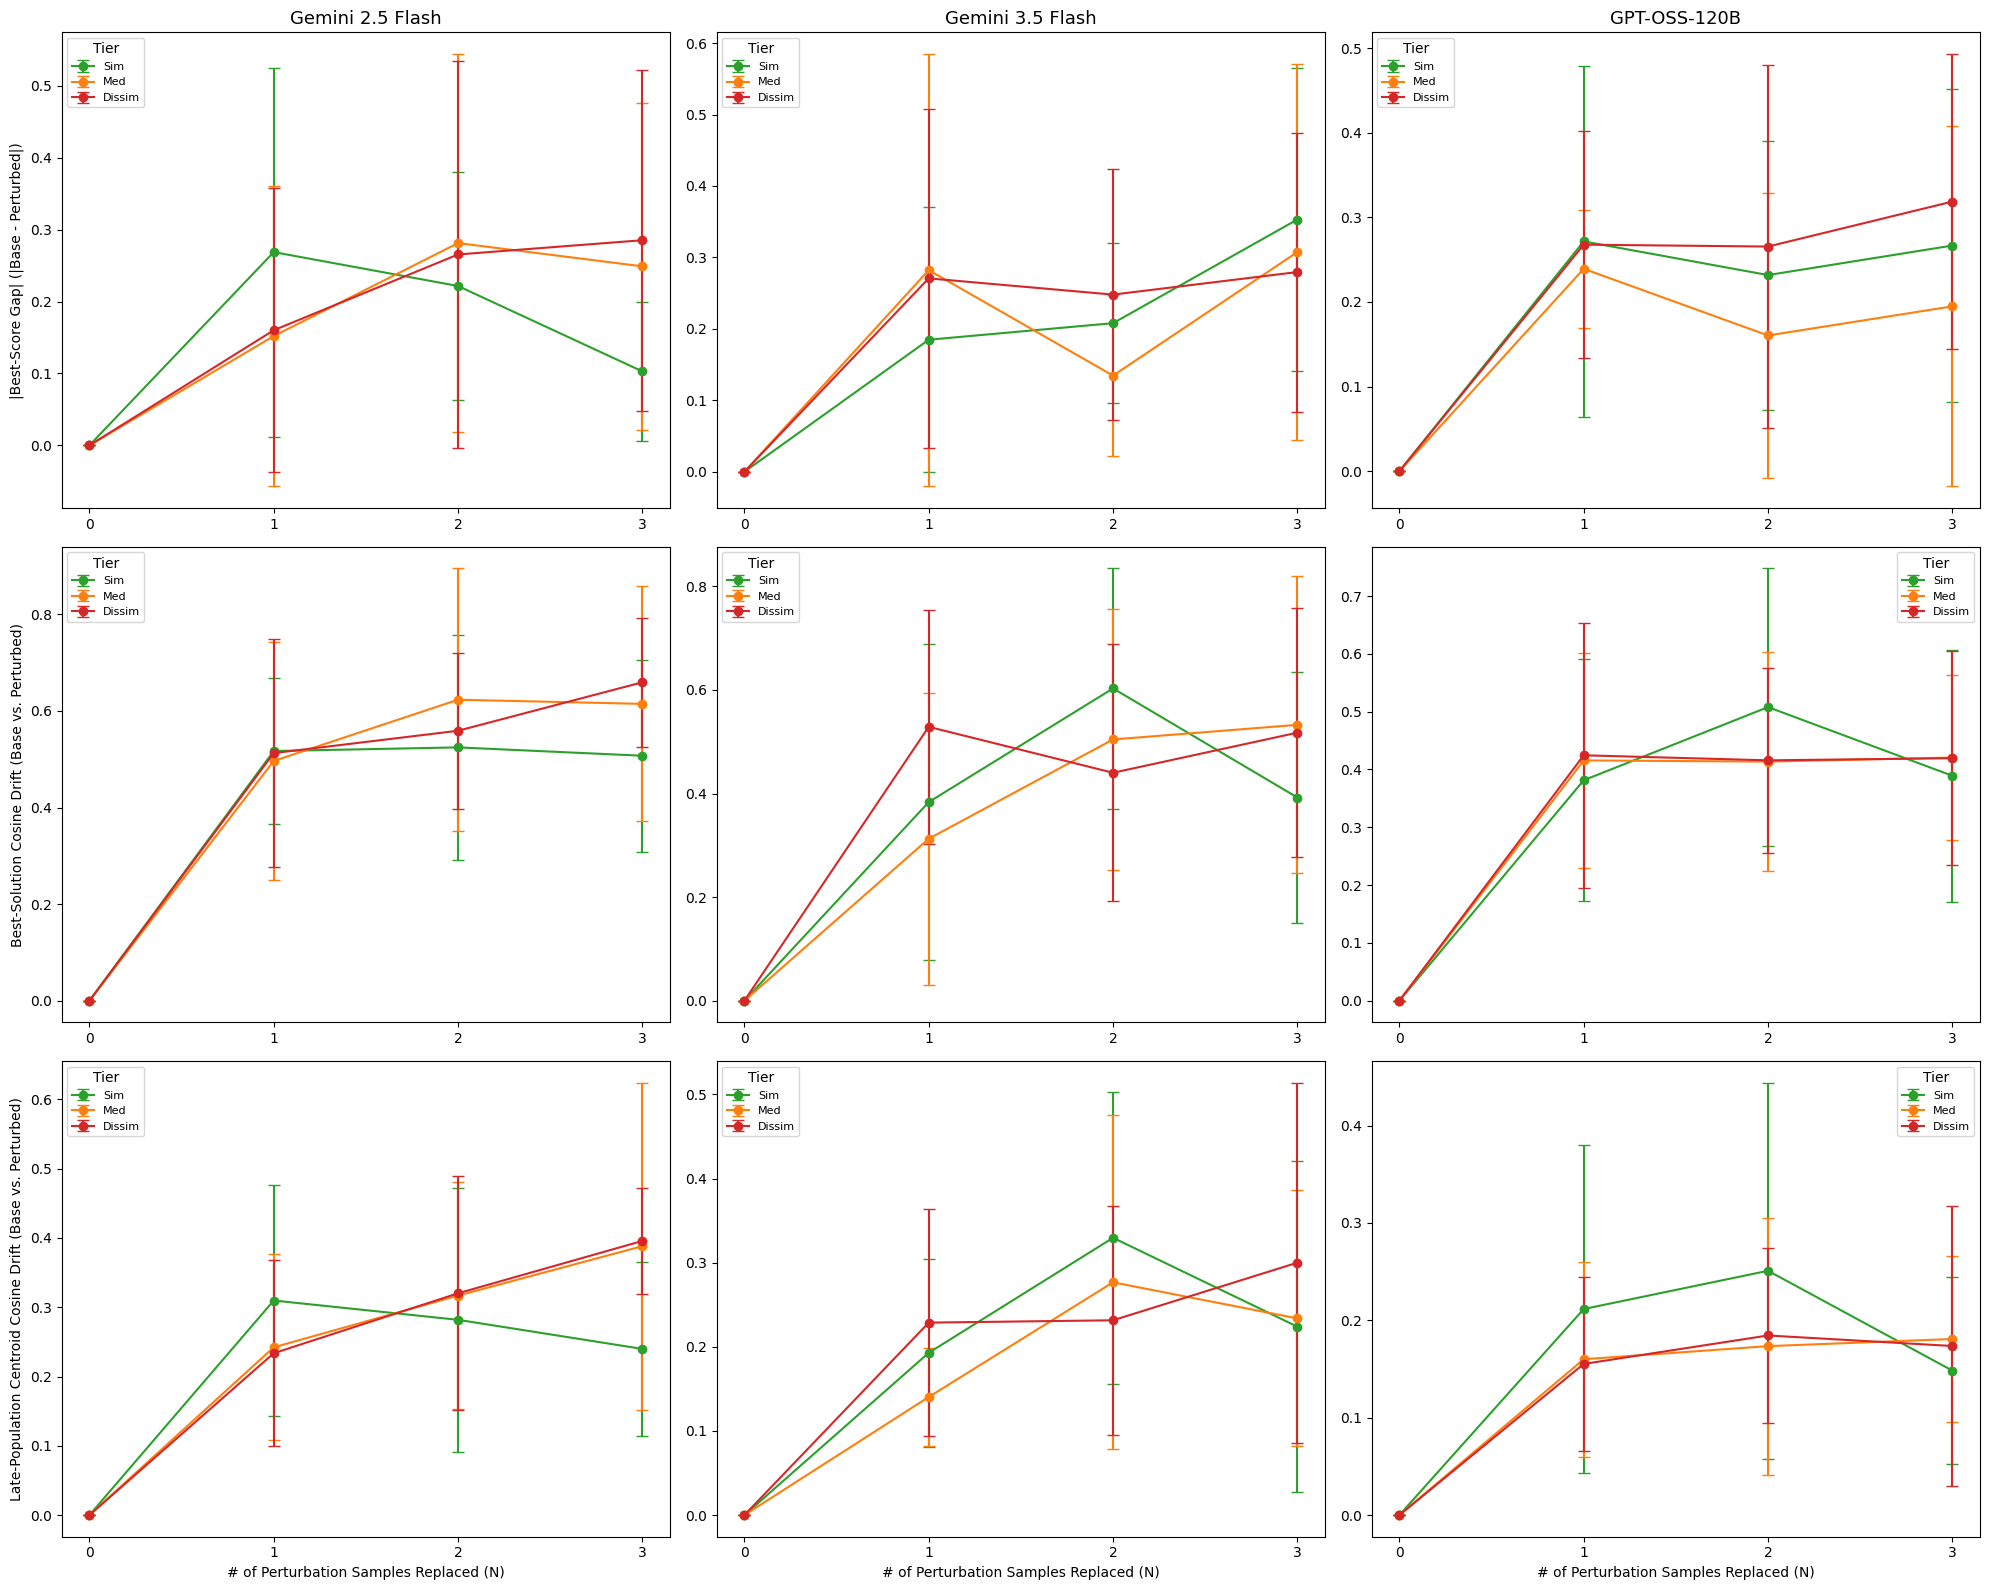

In [15]:
# --- Response curves: aggregate over every knob except N, tier, and model ---
response_metrics = [
    ('score_gap', '|Best-Score Gap| (|Base - Perturbed|)'),
    ('best_solution_drift', 'Best-Solution Cosine Drift (Base vs. Perturbed)'),
    ('late_population_drift', 'Late-Population Centroid Cosine Drift (Base vs. Perturbed)'),
]

curve_agg = response_df.groupby(['tier', 'N', 'model'])[[m for m, _ in response_metrics]].agg(['mean', 'std']).reset_index()
curve_agg.columns = ['tier', 'N', 'model'] + ['_'.join(c) for c in curve_agg.columns[3:]]

tier_colors = {'Sim': 'tab:green', 'Med': 'tab:orange', 'Dissim': 'tab:red'}

# 3 rows (response metric) x 3 columns (model) -- each panel has 3 tier lines.
fig, axes = plt.subplots(len(response_metrics), len(MODEL_ORDER), figsize=(20, 16), squeeze=False)

for row_i, (metric, title) in enumerate(response_metrics):
    for col_i, model_label in enumerate(MODEL_ORDER):
        ax = axes[row_i][col_i]
        model_curve = curve_agg[curve_agg['model'] == model_label]

        for tier in tiers:
            tier_df = model_curve[model_curve['tier'] == tier].sort_values('N')

            # N=0 anchor: Base compared against itself is zero by definition for every metric.
            n_plot = np.concatenate([[0], tier_df['N'].values])
            mean_plot = np.concatenate([[0], tier_df[f'{metric}_mean'].values])
            std_plot = np.concatenate([[0], tier_df[f'{metric}_std'].values])

            ax.errorbar(n_plot, mean_plot, yerr=std_plot, marker='o', capsize=4,
                        label=tier, color=tier_colors[tier])

        ax.set_xticks([0, 1, 2, 3])
        if row_i == 0:
            ax.set_title(model_label, fontsize=13)
        if col_i == 0:
            ax.set_ylabel(title, fontsize=10)
        if row_i == len(response_metrics) - 1:
            ax.set_xlabel('# of Perturbation Samples Replaced (N)')
        ax.legend(title='Tier', fontsize=8)

plt.tight_layout()
plt.show()
